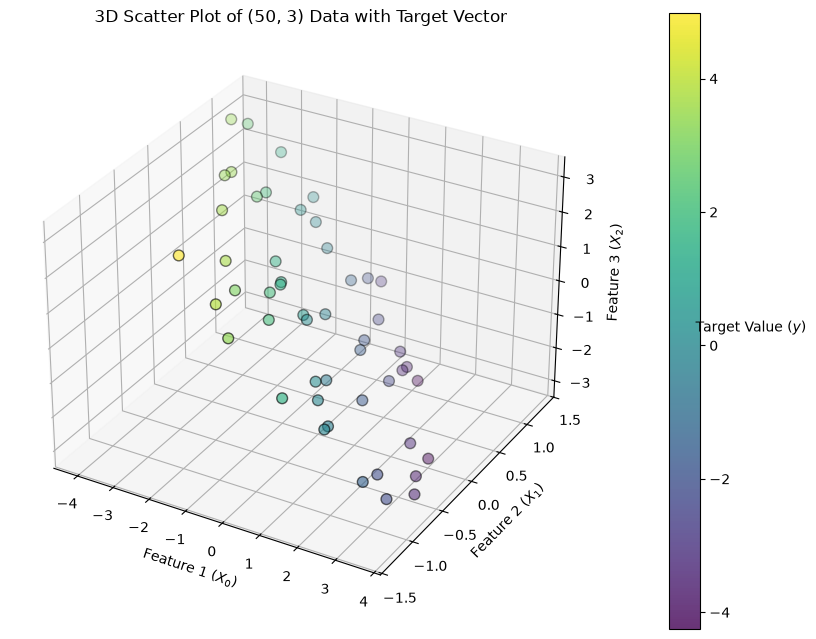

In [42]:
#%matplotlib widget # After installing dependency remove that # at front to get interactive view of graph
import os
import sys

import matplotlib.pyplot as plt

parent_dir = os.path.abspath("..") # parent root path

if parent_dir not in sys.path:
  sys.path.append(parent_dir)

from tests.data_generator import * 

centered = True # toggle to see the differences

X,y = data_generator()

centered_dataset = []
if centered:
  for _ in X:
    centered_feature = _ - np.mean(_)
    centered_dataset.append(centered_feature)
  X = np.array(centered_dataset) # Making centered dataset

y_flat = y.ravel()
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], 
                     c=y_flat, 
                     cmap='viridis', 
                     s=60, 
                     edgecolor='k', 
                     alpha=0.8)

# 4. Labels and styling
ax.set_title("3D Scatter Plot of (50, 3) Data with Target Vector")
ax.set_xlabel("Feature 1 ($X_0$)")
ax.set_ylabel("Feature 2 ($X_1$)")
ax.set_zlabel("Feature 3 ($X_2$)")

# 5. Add a colorbar to show what the colors represent
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Value ($y$)', rotation=0, labelpad=15)

plt.show()

### Implementing PCA for reducing dimensional requirements for given dataset
1. Centering given dataset
2. Finding covariance matrix
3. Eigen vectors and eignen values
4. Making new projection

### Mathematical Insights
with first iteration complex number came inside the pipeline, broke the visualization, along with making more problems
we could have eigen vectors being computed complex due to dataset 
    Q : How to handle intermediate complex numbers into computing eigen vectors ?
**Plot Issues with complex number | How this originated ?**
With computing eigen values, precission up to 16th values makes introduction of complex number into picture which cascades to break the visualization pipeline to visualize the complex numbers

    Eigen values -> Projected values -> Visualization
**Fix**
Make simple use of real function to ignore that pricision into calculating eigen computation


#### Some critical observations with numpy indices to learn
+ Sorting arrays with respect to one another
+ Making slices and cuts with our requirements

```
pack[:,:k]
```
Means we are taking all rows as it is, but taking columns into range which fits up to 
possible exception out of range

**Indexing flips**
np.argsort(values) # returns just the index required for ascending sort | [::-1] directional flip
values[:, indexing]  # **targeting columns sort now row sort with respect to indexing**


Maping vector : [[-0.75572354  0.11016521  0.64555833]
 [ 0.30910937 -0.80903047  0.4999211 ]], with shape : (2, 3)
Original X : (50, 3)
Projected quantity : (2, 50) type check <class 'numpy.ndarray'>


Text(0.5, 1.0, 'Final 2D PCA Projection')

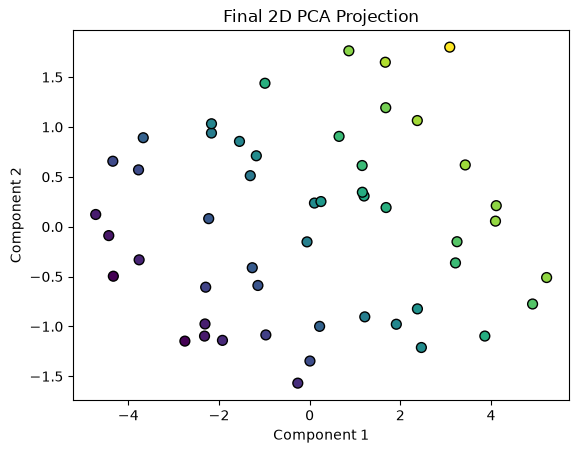

In [43]:
import numpy as np
import matplotlib.pyplot as plt
# Util function


# Mock function | for k pick
def k_sub_dimensional(target_matrix,k):
    '''
    input : target matrix
    output: transformation matrix for maping to lower dimension
    '''
    # with eig and eigh we can induece either complex to break our pipeline or eigh for real number flow :)
    eigen_values, eigen_vectors = np.linalg.eigh(target_matrix)
    indx = np.argsort(eigen_values)[::-1]

    eigen_vectors = eigen_vectors[:, indx]  # sorting columns of eigen vector matrix

    return eigen_vectors[:,: k].T 

covariance_matrix = X.T @ X  # shapes d x n n x d -> d x d

maping_vector = k_sub_dimensional(covariance_matrix, 2)
print(f"Maping vector : {maping_vector}, with shape : {maping_vector.shape}")

# We can now Project the original dataset into this new dimension

print(f"Original X : {X.shape}")
projected_dataset = maping_vector @ X.T  # All data points expressed into 2 dimension 
print(f"Projected quantity : {projected_dataset.shape} type check {type(projected_dataset)}")

component_1 = projected_dataset[0, :].real  # First new feature direction of X
component_2 = projected_dataset[1, :].real  # Second new feature direction of X

projected_X = np.column_stack((component_1, component_2))

plt.scatter(x=component_1, y=component_2, c=y.ravel(), cmap='viridis', edgecolor='k', s=50)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Final 2D PCA Projection")






X : (50, 2) with y : (50, 1)
Weight :
[[0.79183064]
 [1.55478728]] with shape (2, 1)
Testing inputs:
[[-0.26158823 -1.56902978]
 [ 3.86371459 -1.09686098]]
Predictions:
[-2.64664112  1.35402208]


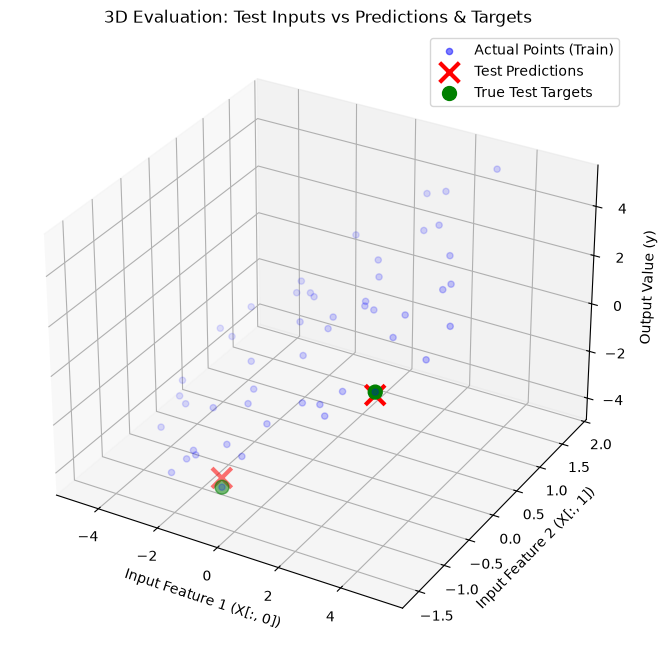

In [61]:
import numpy as np
import matplotlib.pyplot as plt

y = y.reshape(-1, 1)
X = projected_X

print(f"X : {X.shape} with y : {y.shape}")

#  FIX 1: Correct OLS Normal Equation formula: (X^T * X)^(-1) * X^T * y
weight = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)
# No need to transpose weight anymore; it will be shape (2, 1)

print(f"Weight :\n{weight} with shape {weight.shape}")

# Use the weight for predictions
# Slicing the first two rows as individual points: shape (1, 2)
t1 = X[0, :].reshape(1, -1)
t2 = X[1, :].reshape(1, -1)

# FIX 2: Prediction points: Feature inputs (1x2) dotted with Weight vector (2x1) -> scalar prediction
p1 = t1.dot(weight)
p2 = t2.dot(weight)

# Stack elements cleanly for straightforward plotting arrays
test_inputs = np.vstack([t1, t2])          # Shape: (2, 2)
predictions = np.array([p1[0,0], p2[0,0]])  # Shape: (2,)

print(f"Testing inputs:\n{test_inputs}")
print(f"Predictions:\n{predictions}")

# --- Plotting Module ---
actual_targets = y.flatten()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Training data coordinates
x_0 = X[:, 0]
x_1 = X[:, 1]

# Plot Training Set
ax.scatter(x_0, x_1, actual_targets, color='blue', label='Actual Points (Train)', alpha=0.5)

# FIX 3: Plot the two test predictions accurately over their matching X, Y input coordinates
ax.scatter(test_inputs[:, 0], test_inputs[:, 1], predictions, 
           color='red', marker='x', s=200, linewidths=3, label='Test Predictions')

# Optional visual aid: Add actual test targets if you want to see the error gap
ax.scatter(test_inputs[:, 0], test_inputs[:, 1], actual_targets[:2], color='green', s=100, label='True Test Targets')

ax.set_xlabel('Input Feature 1 (X[:, 0])')
ax.set_ylabel('Input Feature 2 (X[:, 1])')
ax.set_zlabel('Output Value (y)')
ax.set_title('3D Evaluation: Test Inputs vs Predictions & Targets')
ax.legend()

plt.show()
